In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from rcgp.morcgp import MORCGP_LMC

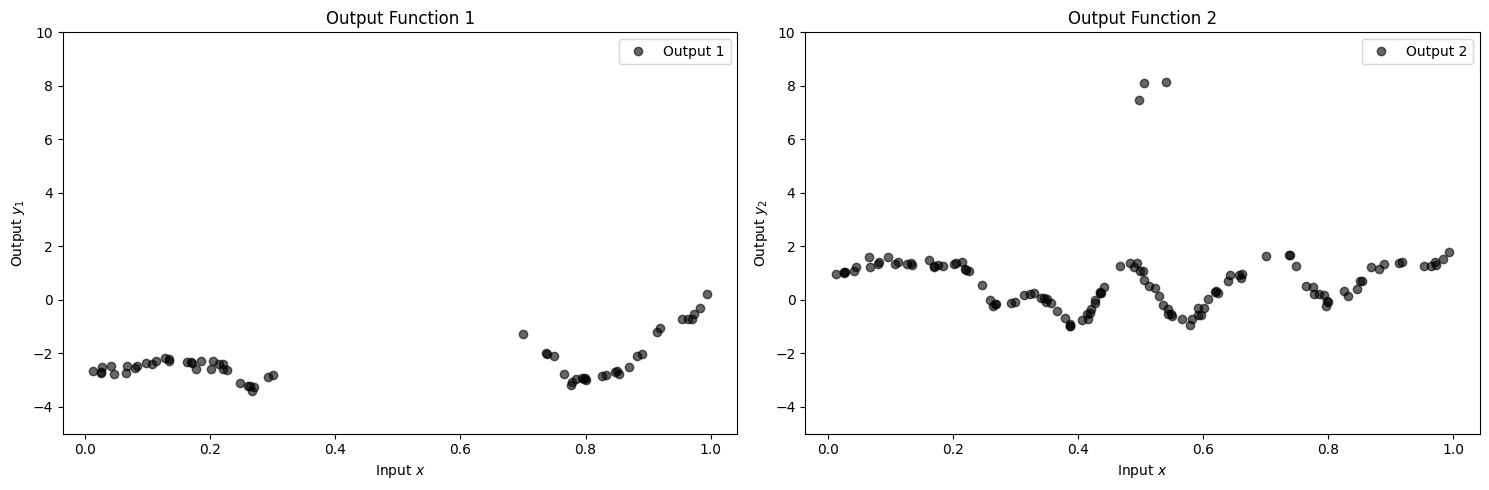

In [2]:
# Set seed for reproducibility
np.random.seed(2)

# 1. Parameters
N = 120
T = 2  # Number of outputs
Q = 2  # Number of coregionalization matrices
d = 1  # Input dimension

# 2. Fixed Coregionalization Matrices (B_q)
# These must be positive semi-definite. 
# We'll create them as B = W*W^T + diag(v)
B1 = np.array([[1.0, 0.8], 
               [0.8, 1.0]])  # Strong positive correlation

B2 = np.array([[1.5, -0.7], 
               [-0.7, 0.5]]) # Negative correlation component

Bs = np.array([B1, B2])
lengthscales = np.array([0.05, 0.5])  # Lengthscales for the kernels
noise_variance = np.array([0.01, 0.01])  # Noise variance for the outputs
epsilon = 0.025
epsilons = np.array([epsilon, epsilon])  # Outlier proportions for each output

# 3. Generate Inputs (x)
X = np.sort(np.random.uniform(0, 1, (N, 1)), axis=0)

# 4. Define Kernels (k_q)
def rbf_kernel(x1, x2, lengthscale):
    sqdist = np.sum(x1**2, 1).reshape(-1, 1) + np.sum(x2**2, 1) - 2 * np.dot(x1, x2.T)
    return np.exp(-0.5 / lengthscale**2 * sqdist)

# Kernel 1: Long range / Kernel 2: Short range (oscillatory)
K1 = rbf_kernel(X, X, lengthscale=lengthscales[0])
K2 = rbf_kernel(X, X, lengthscale=lengthscales[1])

# 5. Construct the Multi-output Covariance Matrix (K_LMC)
# The resulting matrix size will be (N*T, N*T)
K_LMC = np.kron(B1, K1) + np.kron(B2, K2)

# Add a small jitter for numerical stability
K_LMC += 1e-6 * np.eye(N * T)

# 6. Sample from the Multivariate Normal
# Mean is assumed to be zero
mu = np.zeros(N * T)
f_flat = np.random.multivariate_normal(mu, K_LMC)

# Reshape f back to (N, T)
f = f_flat.reshape(T, N).T
y = f + np.random.normal(0, np.sqrt(noise_variance), f.shape)

# Outliers
outlier_range = np.where((X >= 0.45) & (X <= 0.55))[0]
outlier_indices = np.random.choice(outlier_range, int(epsilon*N), replace=False)
y[outlier_indices, 1] = np.random.normal(loc=8, scale=0.5, size=outlier_indices.shape[0])

missing_mask = ((X.flatten() >= 0.3) & (X.flatten() <= 0.7))
y[missing_mask, 0] = np.nan  # Set to NaN to indicate missing values

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for i in range(T):
    axs[i].plot(X.flatten(), y[:, i], 'o', color='black', alpha=0.6, label=f'Output {i+1}')
    axs[i].set_title(f"Output Function {i+1}")
    axs[i].set_xlabel("Input $x$")
    axs[i].set_ylabel(f"Output $y_{i+1}$")
    axs[i].legend()
    axs[i].set_ylim(-5, 10)

plt.tight_layout()

In [6]:
morcgp_LMC = MORCGP_LMC(D=2, mean=0, noise_var=noise_variance, Bs=Bs, lengthscales=lengthscales)
morcgp_LMC.fit(X, y, epsilons=epsilons, robust=True)

x_test = np.linspace(0, 1, 100).reshape(-1, 1)
mu_morcgp_lmc, var_morcgp_lmc = morcgp_LMC.predict(x_test)
std_morcgp_lmc = np.sqrt(var_morcgp_lmc + morcgp_LMC.noise_var)

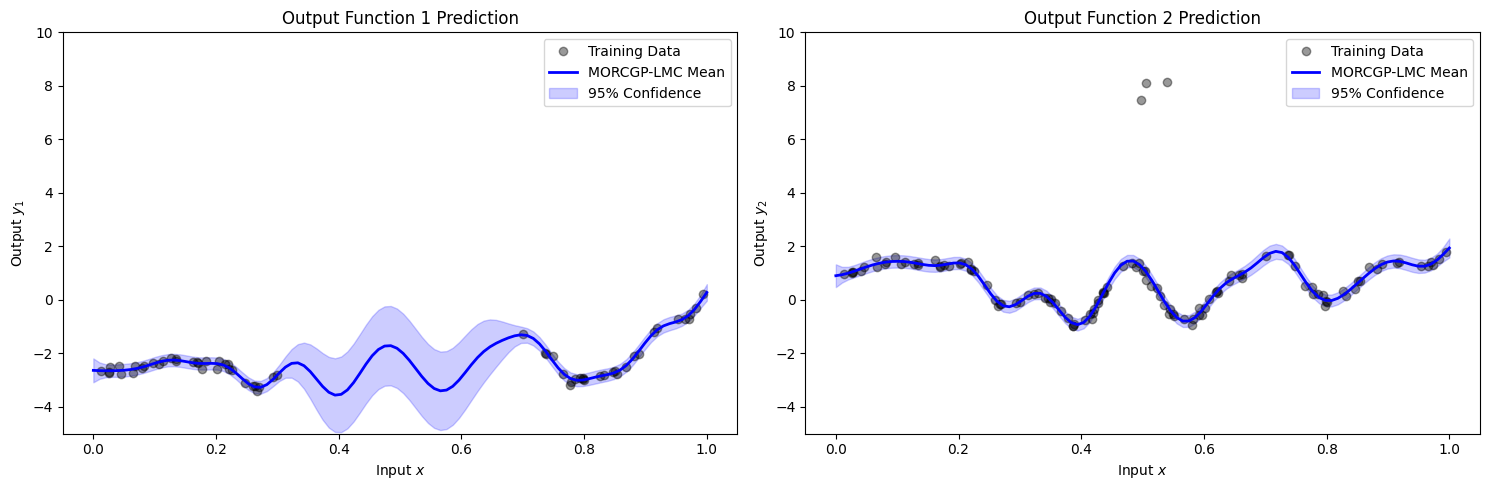

In [7]:
# Plotting the predictions over the training data
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

for i in range(T):
    # 1. Plot the training data points
    axs[i].plot(X.flatten(), y[:, i], 'o', color='black', alpha=0.4, label='Training Data')
    
    # 2. Plot the predicted Mean
    axs[i].plot(x_test.flatten(), mu_morcgp_lmc[:, i], color='blue', lw=2, label='MORCGP-LMC Mean')
    
    # 3. Plot the Confidence Interval (Mean +/- 2*std)
    # Using the standard deviation calculated with noise for the predictive interval
    lower = mu_morcgp_lmc[:, i] - 2 * std_morcgp_lmc[:, i]
    upper = mu_morcgp_lmc[:, i] + 2 * std_morcgp_lmc[:, i]
    
    axs[i].fill_between(x_test.flatten(), lower, upper, color='blue', alpha=0.2, label='95% Confidence')
    
    # Formatting
    axs[i].set_title(f"Output Function {i+1} Prediction")
    axs[i].set_xlabel("Input $x$")
    axs[i].set_ylabel(f"Output $y_{i+1}$")
    axs[i].legend(loc='upper right')

    axs[i].set_ylim(-5, 10)
    
plt.tight_layout()
plt.show()